In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [2]:
data = pd.read_csv("five_minute.csv")

In [3]:
data.head()

,time,price
0,2019-01-01 22:00:00+00:00,1.14658
1,2019-01-01 22:05:00+00:00,1.14635
2,2019-01-01 22:10:00+00:00,1.14632
3,2019-01-01 22:15:00+00:00,1.14632
4,2019-01-01 22:20:00+00:00,1.14653


In [4]:
data["returns"] = np.log(data.price/data.price.shift(1))

In [5]:
lags = 5
cols = []

for lag in range(1,lags+1):
    col = "lag{}".format(lag)
    data[col] = data.returns.shift(lag)
    cols.append(col)

data.dropna(inplace=True)

In [6]:
data.head()

,time,price,returns,lag1,lag2,lag3,lag4,lag5
6,2019-01-01 22:30:00+00:00,1.146455,-0.000017,-0.000048,0.000183,0.000000,-0.000026,-0.000201
7,2019-01-01 22:35:00+00:00,1.146455,0.000000,-0.000017,-0.000048,0.000183,0.000000,-0.000026
8,2019-01-01 22:40:00+00:00,1.146370,-0.000074,0.000000,-0.000017,-0.000048,0.000183,0.000000
9,2019-01-01 22:45:00+00:00,1.146315,-0.000048,-0.000074,0.000000,-0.000017,-0.000048,0.000183
10,2019-01-01 22:50:00+00:00,1.146475,0.000140,-0.000048,-0.000074,0.000000,-0.000017,-0.000048


In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
lm = LinearRegression(fit_intercept=True)

In [11]:
lm.fit(data[cols], data["returns"])

LinearRegression()

In [12]:
data["pred"] = lm.predict(data[cols].values)

C:\Users\Bello\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [13]:
data

,time,price,returns,lag1,lag2,lag3,lag4,lag5,pred
6,2019-01-01 22:30:00+00:00,1.146455,-0.000017,-0.000048,0.000183,0.000000,-0.000026,-0.000201,1.656886e-06
7,2019-01-01 22:35:00+00:00,1.146455,0.000000,-0.000017,-0.000048,0.000183,0.000000,-0.000026,1.138024e-06
8,2019-01-01 22:40:00+00:00,1.146370,-0.000074,0.000000,-0.000017,-0.000048,0.000183,0.000000,-1.132699e-06
9,2019-01-01 22:45:00+00:00,1.146315,-0.000048,-0.000074,0.000000,-0.000017,-0.000048,0.000183,1.614338e-06
10,2019-01-01 22:50:00+00:00,1.146475,0.000140,-0.000048,-0.000074,0.000000,-0.000017,-0.000048,1.700632e-06
...,...,...,...,...,...,...,...,...,...
73715,2019-12-30 23:35:00+00:00,1.120180,-0.000004,-0.000112,-0.000018,0.000022,-0.000004,0.000089,3.239091e-06
73716,2019-12-30 23:40:00+00:00,1.120210,0.000027,-0.000004,-0.000112,-0.000018,0.000022,-0.000004,-3.761738e-08
73717,2019-12-30 23:45:00+00:00,1.120295,0.000076,0.000027,-0.000004,-0.000112,-0.000018,0.000022,-1.638845e-06
73718,2019-12-30 23:50:00+00:00,1.120275,-0.000018,0.000076,0.000027,-0.000004,-0.000112,-0.000018,-2.483698e-06


In [14]:
data.pred = np.sign(data.pred)

In [15]:
data.pred.value_counts()

pred
-1.0    39610
 1.0    34104
Name: count, dtype: int64

In [16]:
hits = np.sign(data.returns*data.pred).value_counts()

In [17]:
hits

 1.0    37493
-1.0    34263
 0.0     1958
Name: count, dtype: int64

In [18]:
hits[1.0]/sum(hits)

np.float64(0.5086279404183737)

In [19]:
data["strategy"] = data.pred*data.returns

In [20]:
data["creturns"] = data["returns"].cumsum().apply(np.exp)
data["cstrategy"] = data["strategy"].cumsum().apply(np.exp)


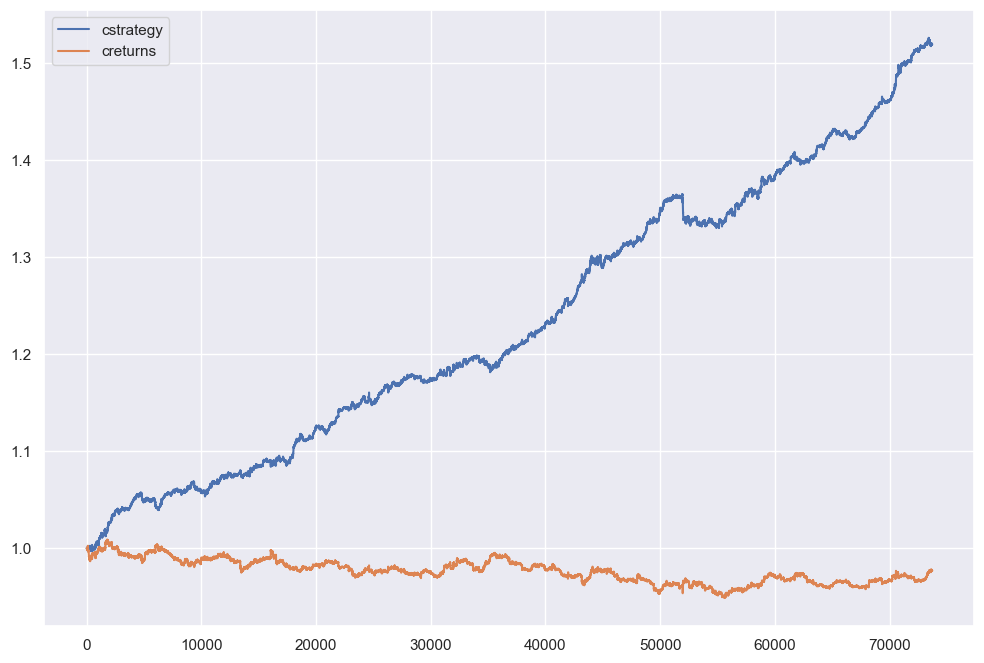

In [21]:
data[["cstrategy","creturns"]].plot(figsize = (12,8))
plt.show()

In [22]:
data["trades"] = data.pred.diff().fillna(0).abs()

In [23]:
data.trades.value_counts()

trades
0.0    37100
2.0    36614
Name: count, dtype: int64

In [41]:
test_data = pd.read_csv("test_set.csv",parse_dates=["time"],index_col="time")

In [42]:
test_data

,price
time,
2020-01-01 22:00:00+00:00,1.121325
2020-01-01 22:05:00+00:00,1.121250
2020-01-01 22:10:00+00:00,1.121250
2020-01-01 22:15:00+00:00,1.121460
2020-01-01 22:20:00+00:00,1.121540
...,...
2020-08-30 23:35:00+00:00,1.190895
2020-08-30 23:40:00+00:00,1.191240
2020-08-30 23:45:00+00:00,1.191515


In [43]:
test_data["returns"] = np.log(test_data/test_data.shift(1))

In [44]:
test_data.head()

,price,returns
time,,
2020-01-01 22:00:00+00:00,1.121325,NaN
2020-01-01 22:05:00+00:00,1.121250,-0.000067
2020-01-01 22:10:00+00:00,1.121250,0.000000
2020-01-01 22:15:00+00:00,1.121460,0.000187
2020-01-01 22:20:00+00:00,1.121540,0.000071


In [50]:
 test_cols = []

In [51]:
for lag in range(1,lags+1):
    col = "lag{}".format(lag)
    test_data[col] = test_data.returns.shift(lag)
    test_cols.append(col)
    
test_data.dropna(inplace=True)

In [52]:
test_data.head()

,price,returns,lag1,lag2,lag3,lag4,lag5
time,,,,,,,
2020-01-01 23:05:00+00:00,1.122005,0.000080,0.000357,-0.000031,-0.000004,0.000031,0.000004
2020-01-01 23:10:00+00:00,1.122010,0.000004,0.000080,0.000357,-0.000031,-0.000004,0.000031
2020-01-01 23:15:00+00:00,1.121980,-0.000027,0.000004,0.000080,0.000357,-0.000031,-0.000004
2020-01-01 23:20:00+00:00,1.122055,0.000067,-0.000027,0.000004,0.000080,0.000357,-0.000031
2020-01-01 23:25:00+00:00,1.122100,0.000040,0.000067,-0.000027,0.000004,0.000080,0.000357


In [53]:
test_cols

['lag1', 'lag2', 'lag3', 'lag4', 'lag5']

In [54]:
test_data["pred"] = lm.predict(test_data[test_cols].values)

C:\Users\Bello\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [55]:
test_data.head()

,price,returns,lag1,lag2,lag3,lag4,lag5,pred
time,,,,,,,,
2020-01-01 23:05:00+00:00,1.122005,0.000080,0.000357,-0.000031,-0.000004,0.000031,0.000004,-1.237460e-05
2020-01-01 23:10:00+00:00,1.122010,0.000004,0.000080,0.000357,-0.000031,-0.000004,0.000031,-4.098914e-06
2020-01-01 23:15:00+00:00,1.121980,-0.000027,0.000004,0.000080,0.000357,-0.000031,-0.000004,7.604648e-07
2020-01-01 23:20:00+00:00,1.122055,0.000067,-0.000027,0.000004,0.000080,0.000357,-0.000031,-3.435924e-07
2020-01-01 23:25:00+00:00,1.122100,0.000040,0.000067,-0.000027,0.000004,0.000080,0.000357,-4.070854e-06


In [57]:
test_data.pred = np.sign(test_data.pred)

In [58]:
hits = np.sign(test_data.pred*test_data.returns).value_counts()

In [59]:
hits[1.0]/sum(hits)

np.float64(0.5063416808493395)

In [62]:
test_data["strategy"] = test_data.pred*test_data.returns

In [63]:
test_data["creturns"] = test_data["returns"].cumsum().apply(np.exp)
test_data["cstrategy"] = test_data["strategy"].cumsum().apply(np.exp)

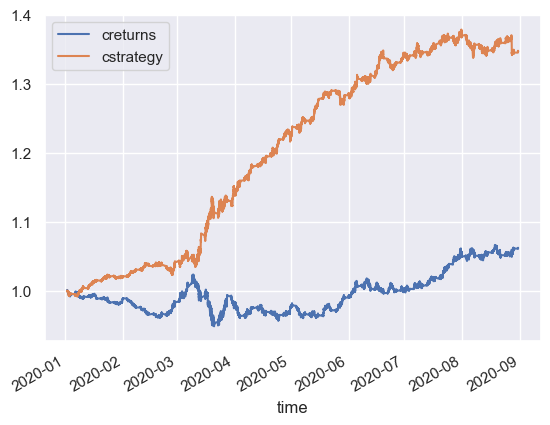

In [64]:
test_data[["creturns","cstrategy"]].plot()
plt.show()

In [65]:
test_data["trades"] = test_data.pred.diff().fillna(0).abs()

In [66]:
test_data.trades.value_counts()

trades
0.0    25188
2.0    24168
Name: count, dtype: int64

Classification Problem - Logistic regression

In [67]:
data = pd.read_csv("five_minute.csv",parse_dates=["time"],index_col="time")

In [68]:
data["returns"] = np.log(data/data.shift(1))

In [69]:
data

,price,returns
time,,
2019-01-01 22:00:00+00:00,1.146580,NaN
2019-01-01 22:05:00+00:00,1.146350,-0.000201
2019-01-01 22:10:00+00:00,1.146320,-0.000026
2019-01-01 22:15:00+00:00,1.146320,0.000000
2019-01-01 22:20:00+00:00,1.146530,0.000183
...,...,...
2019-12-30 23:35:00+00:00,1.120180,-0.000004
2019-12-30 23:40:00+00:00,1.120210,0.000027
2019-12-30 23:45:00+00:00,1.120295,0.000076


In [70]:
data["direction"] = np.sign(data.returns)

In [71]:
data.direction.value_counts()

direction
 1.0    36058
-1.0    35702
 0.0     1959
Name: count, dtype: int64

In [72]:
lags = 5
cols = []

In [73]:
for lag in range(1, lags+1):
    col = "lag{}".format(lag)
    data[col] = data.returns.shift(lag)
    cols.append(col)
data.dropna(inplace=True)

In [74]:
data.head()

,price,returns,direction,lag1,lag2,lag3,lag4,lag5
time,,,,,,,,
2019-01-01 22:30:00+00:00,1.146455,-0.000017,-1.0,-0.000048,0.000183,0.000000,-0.000026,-0.000201
2019-01-01 22:35:00+00:00,1.146455,0.000000,0.0,-0.000017,-0.000048,0.000183,0.000000,-0.000026
2019-01-01 22:40:00+00:00,1.146370,-0.000074,-1.0,0.000000,-0.000017,-0.000048,0.000183,0.000000
2019-01-01 22:45:00+00:00,1.146315,-0.000048,-1.0,-0.000074,0.000000,-0.000017,-0.000048,0.000183
2019-01-01 22:50:00+00:00,1.146475,0.000140,1.0,-0.000048,-0.000074,0.000000,-0.000017,-0.000048


In [75]:
means = data[cols].mean()
stand_devs = data[cols].std()

In [76]:
data[cols] = (data[cols]-means)/stand_devs

In [78]:
data[cols].mean()

lag1    1.041032e-17
lag2    1.542269e-18
lag3   -1.118145e-17
lag4    5.397942e-18
lag5   -1.079588e-17
dtype: float64

In [79]:
from sklearn.linear_model import LogisticRegression

In [80]:
lm = LogisticRegression(C = 1e6,max_iter = 100000, multi_class = "ovr")

In [81]:
lm.fit(data[cols],data.direction)

C:\Users\Bello\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=1000000.0, max_iter=100000, multi_class='ovr')

In [82]:
data["pred"] = lm.predict(data[cols])

In [83]:
data.pred.value_counts()

pred
 1.0    41414
-1.0    32300
Name: count, dtype: int64

In [84]:
from sklearn.metrics import accuracy_score

In [85]:
accuracy_score(data.direction,data.pred)

0.5105678704181024

In [86]:
data["strategy"] = data.pred*data.returns

In [87]:
data["creturns"] = data["returns"].cumsum().apply(np.exp)
data["cstrategy"] = data["strategy"].cumsum().apply(np.exp)

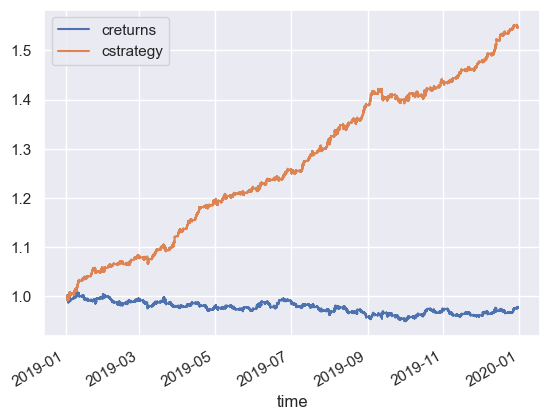

In [88]:
data[["creturns","cstrategy"]].plot()
plt.show()

In [89]:
data["trades"] = data.pred.diff().fillna(0).abs()